In [45]:
#Traffic PINN 1D test
#Check point 
#Import libraries



In [46]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


In [47]:
# Craete 2D mesh Grid
#1. initialise x array
#2. initialise t array
#3. use meshgrid to create 2D mesh
N_x = 200
start_length = 0
end_length = 10 #(km)
N_t = 500
start_time = 0
end_time = 0.25#(hr)



arr_x = np.linspace(start_length, end_length, N_x)
arr_t = np.linspace(start_time, end_time, N_t)

X_grid, T_grid = np.meshgrid(arr_x, arr_t)
print (X_grid, T_grid)
#plot grid

[[ 0.          0.05025126  0.10050251 ...  9.89949749  9.94974874
  10.        ]
 [ 0.          0.05025126  0.10050251 ...  9.89949749  9.94974874
  10.        ]
 [ 0.          0.05025126  0.10050251 ...  9.89949749  9.94974874
  10.        ]
 ...
 [ 0.          0.05025126  0.10050251 ...  9.89949749  9.94974874
  10.        ]
 [ 0.          0.05025126  0.10050251 ...  9.89949749  9.94974874
  10.        ]
 [ 0.          0.05025126  0.10050251 ...  9.89949749  9.94974874
  10.        ]] [[0.       0.       0.       ... 0.       0.       0.      ]
 [0.000501 0.000501 0.000501 ... 0.000501 0.000501 0.000501]
 [0.001002 0.001002 0.001002 ... 0.001002 0.001002 0.001002]
 ...
 [0.248998 0.248998 0.248998 ... 0.248998 0.248998 0.248998]
 [0.249499 0.249499 0.249499 ... 0.249499 0.249499 0.249499]
 [0.25     0.25     0.25     ... 0.25     0.25     0.25    ]]


In [48]:
# 1. Base traffic density of 30 everywhere along the 200 spatial points
rho_0 = np.ones(N_x) * 30.0 #30vehicles /km
# 2. Define the traffic jam bump parameters
amplitude = 90.0  # Spikes the density from 30 up to 120 (30 + 90 = 120)
center = 4.0      # Centered at x = 4 km
spread = 1.0      # How wide the traffic jam stretches

# 3. Add the bell-shaped traffic jam to our baseline
# np.exp() computes e^x. When arr_x is exactly at the center (4.0), 
# this exponential term equals 1, giving us our maximum peak.
rho_0 += amplitude * np.exp(-((arr_x - center) / spread)**2)

print(rho_0)



[ 30.00001013  30.0000151   30.0000224   30.00003307  30.00004857
  30.00007097  30.00010318  30.00014926  30.00021482  30.00030762
  30.0004383   30.00062134  30.00087639  30.00122991  30.00171733
  30.00238583  30.00329787  30.00453559  30.00620642  30.00844997
  30.01144657  30.01542775  30.02068885  30.02760429  30.03664575
  30.04840355  30.06361178  30.08317724  30.10821266  30.14007425
  30.1804036   30.23117387  30.2947399   30.37389165  30.47191008
  30.5926242   30.74046778  30.92053351  31.13862229  31.4012848
  31.71585186  32.09045016  32.53399932  33.05618626  33.66741277
  34.37871235  35.20163277  36.1480814   37.23013121  38.4597864
  39.84870809  41.40790201  43.14737189  45.07574427  47.19987241
  49.52442882  52.05149808  54.78018298  57.70623847  60.82174875
  64.11486309  67.56960582  71.16577473  74.87894062  78.68055817
  82.53819531  86.41588443  90.2745949   94.07282141  97.76727857
 101.31368713 104.66763335 107.78547893 110.62529613 113.14780032
 115.3172512

In [49]:
def traffic_flow(rho):
    v_max = 100.0
    rho_max = 150.0
    return v_max * rho * (1.0 - rho / rho_max)

In [50]:
# numerical schemes 
#lax fredrichs
#1. initialise a rho_history to store old data this should be a (t,x) grid not (x, t) as we need it to match matrix multiplications

rho_history = np.zeros((N_t, N_x))

# for t=0, the rho history rom should be rho_0
rho_history[0,:] = rho_0

#print (rho_history)

#Define dx(delta x) since total length is 10km, and number of intervals are 200 (starting from 0) so intervals are 199
dx = end_length/ (N_x-1)
#similarly Dt delta t is end time/ interval 500-1 = 499
dt = end_time/(N_t-1)
print (dx)
print (dt)

CFL = v_max *(dt/(2*dx))

print (CFL)

####
# Loop through time steps
for n in range(0, N_t - 1):
    
    # 1. Create our blank array for the next step
    rho_next = np.zeros(N_x)
    #as per lax fredrichs rule we are trying to calculate the value of the ith term wuing i+1 and i-1
    # 2. Fill in the middle parts
    for i in range(1, N_x - 1):
        avg_density = 0.5 * (rho_history[n, i+1] + rho_history[n, i-1]) # this help smooth out the sudden shock
        
        # 2. Get the traffic flow at the right and left neighbors
        # (Using the flow equation you already built)
        q_right = traffic_flow(rho_history[n, i+1])
        q_left  = traffic_flow(rho_history[n, i-1])
        
        # 3. Compute the change in flow
        flow_change = (dt / (2 * dx)) * (q_right - q_left)
        
        # 4. Save the result for this spot
        rho_next[i] = avg_density - flow_change
        
    # 3. Fill in the edges of our whiteboard (constant boundaries)
    rho_next[0] = rho_history[n, 0]
    rho_next[-1] = rho_history[n, -1]
    
    # 4. Save this finished whiteboard into the history album!
    rho_history[n+1, :] = rho_next
    


0.05025125628140704
0.000501002004008016
0.49849699398797587


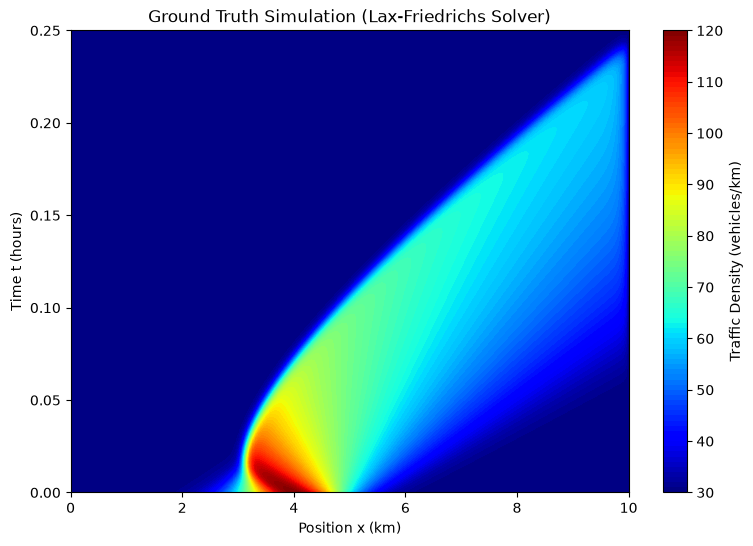

In [51]:
# 1. Create a figure
plt.figure(figsize=(9, 6))

# 2. Use contourf to plot the space-time density
# we use X_grid and T_grid that you made earlier with meshgrid!
contour = plt.contourf(X_grid, T_grid, rho_history, levels=100, cmap='jet')

# 3. Add labels and styling
plt.colorbar(contour, label='Traffic Density (vehicles/km)')
plt.xlabel('Position x (km)')
plt.ylabel('Time t (hours)')
plt.title('Ground Truth Simulation (Lax-Friedrichs Solver)')

# 4. Show the plot
plt.show()